# Illustrate generation of synthetic agglomerate structures

The idea is to have a very simple generator to create sufficient playground for method testing

In [1]:
import meatballsss as mbs
import numpy as np

In [2]:
agglomerate = mbs.VoxelizedMeatball()
agglomerate.create_random_agglomerate(30, 100)

/mnt/c/Users/sdaubner/workspace/meatballsss/meatballsss/fields.py:89: UserWarning: Empty initialization. Please generate a grain structure!
  warnings.warn("Empty initialization. Please generate a grain structure!")


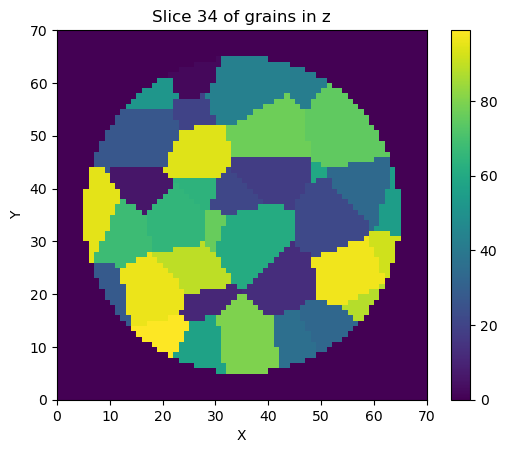

In [3]:
%matplotlib inline
agglomerate.plot_slice('grains', 34)

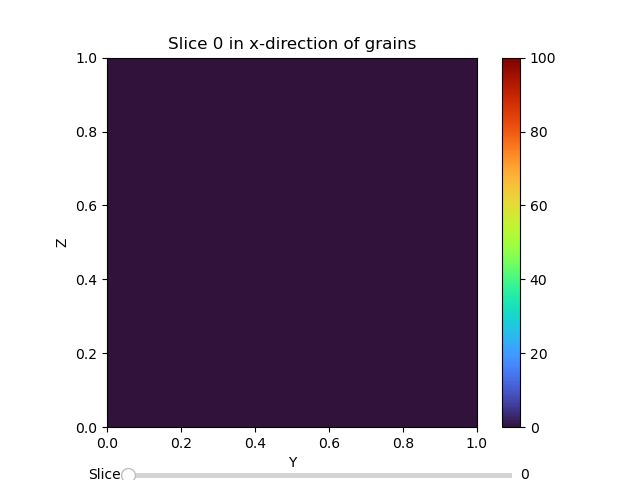

In [4]:
%matplotlib widget
agglomerate.plot_field_interactive("grains", direction='x', colormap='turbo')

In [5]:
radii = [20,50] # [20,50] #[50,80,110] #[30, 80, 100]
seed_nums = [50,100] # [50,100] #[100,150,400] #[50,300,50]

agglomerate.create_structured_agglomerate(radii, seed_nums)

/mnt/c/Users/sdaubner/workspace/meatballsss/meatballsss/fields.py:93: UserWarning: Previous grain map will be over-written!
  warnings.warn("Previous grain map will be over-written!")


In [17]:
colormap = agglomerate.generate_color_map()
print(colormap.shape)
print(colormap[55,55,55])
print(np.max(colormap[:,:,:,0]))


Generating colormap from grain_map and angle_list.
(110, 110, 110, 3)
[0.71684954 0.49841374 0.33888093]
0.9984704690805264


In [16]:
agglomerate.angles

array([[1.13988478e+02, 1.40353717e+01, 6.49754439e+01],
       [1.64059169e+02, 7.68367331e+01, 1.00330263e+02],
       [2.31935912e+01, 1.31767096e+02, 1.80747431e+01],
       [4.96103585e+00, 6.15333263e+01, 1.02355130e+02],
       [1.15811471e+02, 1.76517713e+02, 4.97696934e+01],
       [1.70420887e+02, 6.29631444e+01, 6.51222976e+01],
       [1.60800817e+02, 1.33085617e+02, 2.89535512e+01],
       [1.05302010e+02, 1.72487887e+02, 1.92435972e+01],
       [3.38806375e+01, 1.16175227e+01, 6.87327078e+01],
       [1.19478963e+01, 1.52061885e+02, 1.20972319e+00],
       [3.51652583e+01, 1.82504008e+01, 1.00785348e+02],
       [1.13054627e+02, 7.63804361e+00, 6.73695841e+01],
       [1.79724684e+02, 8.53544155e+01, 1.06113764e+02],
       [2.05034355e+01, 7.62427338e+01, 2.47387353e+01],
       [1.25434787e+02, 1.24934501e+02, 6.49544629e+01],
       [3.73493457e+01, 2.25334283e+01, 1.94517381e+01],
       [9.09891246e+01, 1.47807783e+02, 7.36136106e+01],
       [7.28107502e+01, 1.39307

In [18]:
agglomerate.export_fields_to_vtk()

In [19]:
agglomerate.export_orientations_to_vtk()

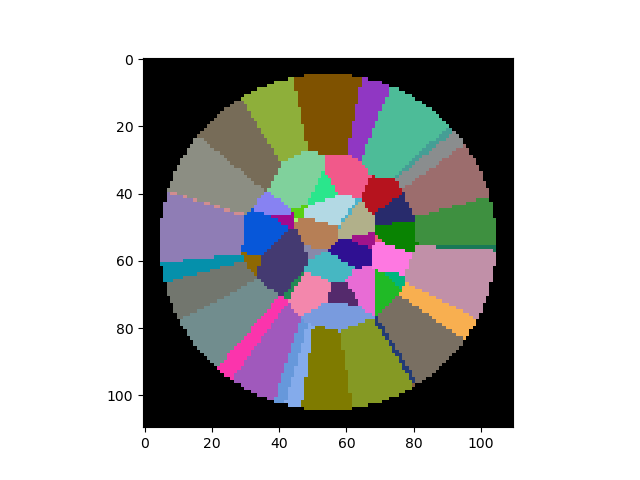

In [23]:
import matplotlib.pyplot as plt
plt.figure()
im = plt.imshow(colormap[55,:,:])

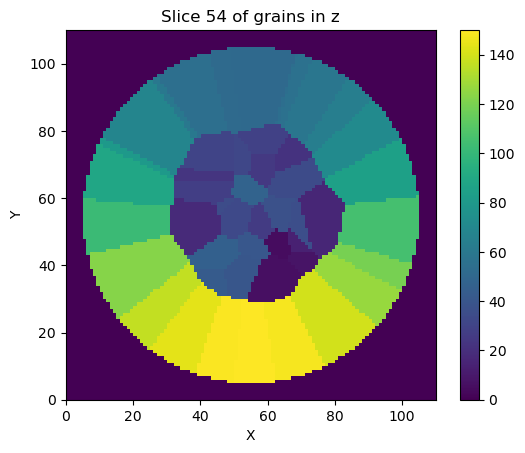

In [25]:
%matplotlib inline
agglomerate.plot_slice('grains', 54)

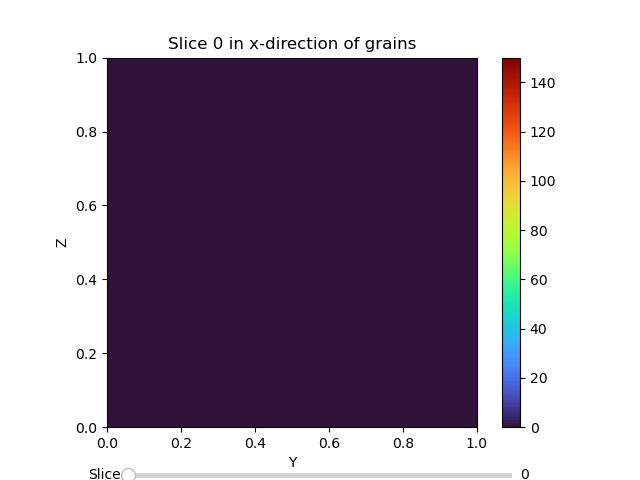

In [7]:
%matplotlib widget
agglomerate.plot_field_interactive("grains", direction='x', colormap='turbo')

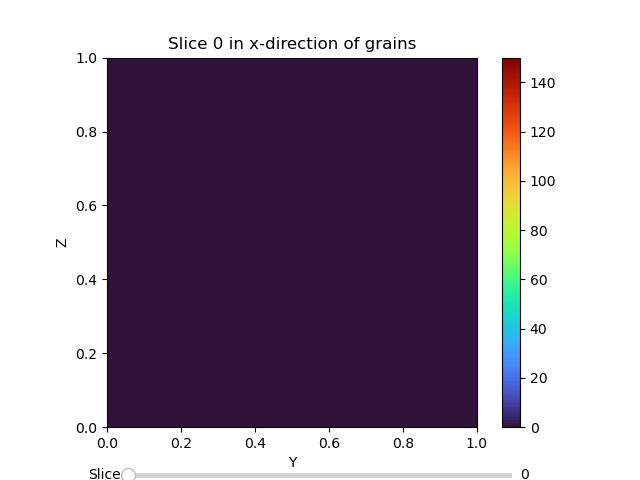

In [12]:
agglomerate.relabel_random_order()
%matplotlib widget
agglomerate.plot_field_interactive("grains", direction='x', colormap='turbo')

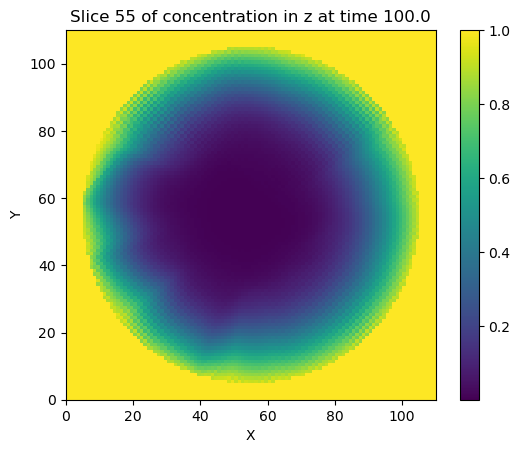

Wall time: 44.3795 s (0.0044 s/iter)
GPU-RAM currently allocated 69.15 MB (127.93 MB reserved)
GPU-RAM maximally allocated 85.16 MB (127.93 MB reserved)


In [13]:
%matplotlib inline
sim = mbs.PITTSolver(agglomerate, diffusivity=[1,1,0.1])
sim.solve(time_increment=0.01, max_iters=10000, frames=20, verbose='plot')

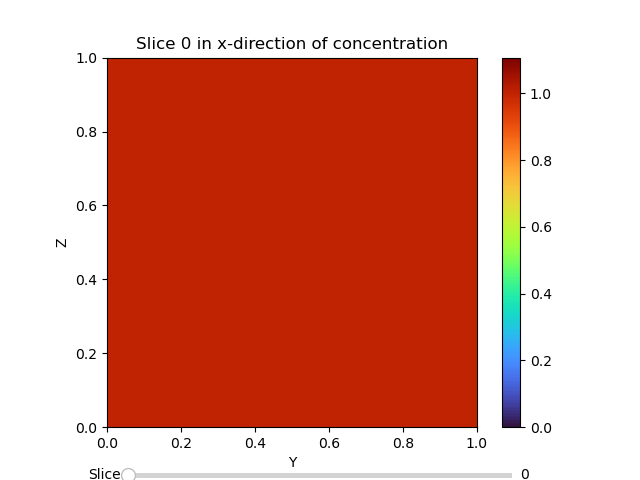

In [14]:
%matplotlib widget
agglomerate.plot_field_interactive("concentration", direction='x', colormap='turbo')